# **Libraries**

In [1]:
!pip install transformers datasets torch scikit-learn evaluate pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# hugging face
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
# pytorch
import torch
# evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
import evaluate

# **Train**

In [3]:
label2id = {"negatif": 0, "netral": 1, "positif": 2}
id2label = {0: "negatif", 1: "netral", 2: "positif"}
NUM_CLASSES = 3
MODEL_NAME = "indobenchmark/indobert-base-p1"
RANDOM_STATE = 42

In [4]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded.


In [5]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Updated path to your specific preprocessed dataset
file_path = '/content/drive/MyDrive/Thesis/final_preprocessed.xlsx'

# Load the dataset
df = pd.read_excel(file_path)

# 1. Basic Cleaning: Drop rows where clean_text or sentiment is missing
df = df.dropna(subset=['clean_text', 'sentiment'])

# 2. Standardize labels (remove whitespace and lowercase) to ensure mapping works
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

# 3. Map labels to IDs
df['sentiment'] = df['sentiment'].map(label2id)

# 4. Final check: Drop any rows where mapping failed (if any unexpected labels existed)
df = df.dropna(subset=['sentiment'])
df['sentiment'] = df['sentiment'].astype(int)

print(f"Dataset loaded and cleaned. Final count: {len(df)} samples.")
display(df.head())
print("Label distribution:")
print(df['sentiment'].value_counts())

Mounted at /content/drive
Dataset loaded and cleaned. Final count: 6028 samples.


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,source,keyword,clean_text,sentiment
0,6a7dbd15-2507-4f2c-bd2c-d36bbc89c640,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,masa Bank BUMN terbesar rating nya 4.1..tadiny...,3,0,NaN,2025-12-15 13:26:18+00:00,"Hai Sahabat @Alexander Luberizky, mohon maaf a...",2025-12-15 13:29:19,NaN,Dataset/dataset\LIVIN_googleplay_DECEMBER_revi...,qris,bank bumn terbesar rating nya ga komplainliat ...,0
1,c7f1469f-42f5-4dad-86eb-13aca28e5cf7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa tidak bisa masuk ke aplikasi livin kami...,2,0,3.1.0,2025-11-04 10:11:46+00:00,"Halo Sahabat @Salma Laudengi, mohon maaf atas ...",2025-11-04 10:33:49,3.1.0,Dataset/dataset\LIVIN_googleplay_NOVEMBER_revi...,login,tidak masuk aplikasi livin peningkatan layanan...,1
2,3bde987d-6726-4ed8-8cc7-de39a3331f68,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"heran aku, kejadian bukan 1 kali jadi di ATM s...",3,0,1.60.0,2025-10-22 21:59:11+00:00,NaN,NaN,1.60.0,Dataset/dataset\GOPAY_googleplay_OCTOBER_revie...,transfer,heran kejadian bukan kali atm saldo bri k tf j...,0
3,91616e30-ada7-4242-8872-ab3e310881f2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Apk nya bagus cmn kebykn nyangkut di e-toll ud...,1,4,1.59.0,2025-10-04 16:41:42+00:00,"Hai Kak Widia, mohon maaf atas ketidaknyamanan...",2025-10-04 18:53:40,1.59.0,Dataset/dataset\GOPAY_googleplay_OCTOBER_revie...,topup,apk nya bagus cmn kebykn nyangkut etoll udh to...,0
4,beffc9f7-fa71-4ab9-9fe8-17c66bab72b0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,knp kalo mau transfer harus upgrade ke gopay p...,4,0,1.64.1,2025-11-26 07:54:47+00:00,NaN,NaN,1.64.1,Dataset/dataset\GOPAY_googleplay_NOVEMBER_revi...,transfer,knp kalo transfer upgrade gopay plus dlu,1


Label distribution:
sentiment
0    4472
2     906
1     650
Name: count, dtype: int64


In [6]:
X = df['clean_text']
y = df['sentiment']
# step 1 — 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
# step 2 — 50% of temp = 10% total test, rest = 10% val
X_val, X_test, y_val, y_test = train_test_split(
X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print(f"Train : {len(X_train)} samples")
print(f"Val : {len(X_val)} samples")
print(f"Test : {len(X_test)} samples")


Train : 4822 samples
Val : 603 samples
Test : 603 samples


In [7]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# build dataframes per split
train_df = pd.DataFrame({'text': X_train.tolist(), 'sentiment': y_train.tolist()})
val_df = pd.DataFrame({'text': X_val.tolist(), 'sentiment': y_val.tolist()})
test_df = pd.DataFrame({'text': X_test.tolist(), 'sentiment': y_test.tolist()})

# convert to HF Dataset and tokenize
def prepare(df):
    ds = Dataset.from_pandas(df)
    ds = ds.map(tokenize_function, batched=True)
    # IMPORTANT: The column must be named "labels" for the Trainer to compute loss
    ds = ds.remove_columns(["text"]).rename_column("sentiment", "labels")
    ds.set_format("torch")
    return ds

dataset_dict = DatasetDict({
    "train" : prepare(train_df),
    "validation" : prepare(val_df),
    "test" : prepare(test_df),
})
print(dataset_dict)

Map:   0%|          | 0/4822 [00:00<?, ? examples/s]

Map:   0%|          | 0/603 [00:00<?, ? examples/s]

Map:   0%|          | 0/603 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4822
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 603
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 603
    })
})


In [8]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = NUM_CLASSES,
    id2label = id2label,
    label2id = label2id,
)

# --- FREEZING LOGIC TO REACH 20-30M PARAMETERS ---
# Standard BERT-base has ~124M total parameters.
# Freezing all but the last 2 layers (~7M per layer) + Pooler/Classifier head
# brings trainable parameters to ~23.5M.

# 1. Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# 2. Unfreeze the last 2 transformer layers (Layer 10 and 11)
for layer in model.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

# 3. Unfreeze the pooler and the classification head
for param in model.bert.pooler.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# Verification
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded — {NUM_CLASSES} output classes.")
print(f"Trainable Parameters: {trainable_params:,}")
if 20_000_000 <= trainable_params <= 35_000_000:
    print("Target range (20-30M) successfully achieved!")

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded — 3 output classes.
Trainable Parameters: 14,768,643


In [9]:
# load once — not inside the function
load_accuracy = evaluate.load("accuracy")
load_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]

    # Calculate AUC ROC for each class and then average (macro or weighted)
    # For multiclass, roc_auc_score needs one-vs-rest strategy
    # Convert labels to one-hot for roc_auc_score if not already
    if len(np.unique(labels)) > 2:
        # Assuming labels are 0, 1, 2 for 3 classes
        labels_one_hot = np.eye(len(label2id))[labels]
        predictions_scores = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
        roc_auc = roc_auc_score(labels_one_hot, predictions_scores, average="weighted", multi_class='ovr')
    else:
        roc_auc = roc_auc_score(labels, predictions)

    return {"accuracy": accuracy, "f1": f1, "roc_auc": roc_auc}

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

In [10]:
training_args = TrainingArguments(
    output_dir = "results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 100, # Updated to 100 epochs
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = "roc_auc",
    logging_steps = 5,
    report_to = "none",
)

### **Improvement: Handling Class Imbalance with Weighted Loss**
Since the 'neutral' class is underrepresented, we can calculate class weights and use a custom Trainer to apply them during training.

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

# 1. Calculate weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
# Keep class_weights on CPU initially, it will be moved to the correct device inside compute_loss
initial_class_weights = torch.tensor(weights, dtype=torch.float)
print(f"Calculated Initial Class Weights (on CPU): {initial_class_weights}")

# 2. Define a Custom Trainer to override compute_loss
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights_tensor=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Move class_weights_tensor to the same device as the model's logits
        # This ensures the loss function receives weights on the correct device (GPU)
        if self.class_weights_tensor is not None:
            # Check if weights are already on the correct device to avoid unnecessary transfers
            if self.class_weights_tensor.device != model.device:
                self.class_weights_tensor = self.class_weights_tensor.to(model.device)

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 3. Initialize the new trainer
weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    # Removed processing_class as it's not a valid argument for Trainer directly.
    # If a data collator is needed, it should be explicitly passed as `data_collator`.
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    class_weights_tensor=initial_class_weights, # Pass the CPU tensor
)

print("Weighted Trainer ready. Run weighted_trainer.train() to see if 'neutral' F1 improves.")

Calculated Initial Class Weights (on CPU): tensor([0.4494, 3.0910, 2.2170])
Weighted Trainer ready. Run weighted_trainer.train() to see if 'neutral' F1 improves.


## **Step 1: Initial Training**
We perform the first training pass using class weights to account for the imbalanced dataset.

In [12]:
import sys
import torchvision.io

# Robust fix for the 'VideoReader' TypeError in datasets library
class DummyVideoReader:
    pass

# Ensure VideoReader is a valid class type for isinstance() checks
if not hasattr(torchvision.io, 'VideoReader') or not isinstance(torchvision.io.VideoReader, type):
    torchvision.io.VideoReader = DummyVideoReader

print("--- PHASE 1: INITIAL TRAINING ---")
weighted_trainer.train()

# Immediate Validation check
initial_val_results = weighted_trainer.evaluate()
print(f"Initial Validation ROC AUC: {initial_val_results['eval_roc_auc']:.4f}")

--- PHASE 1: INITIAL TRAINING ---


Epoch,Training Loss,Validation Loss,Accuracy,F1,Roc Auc
1,0.630856,0.582237,0.822554,0.833113,0.916791
2,0.677367,0.602330,0.827529,0.838441,0.923236
3,0.505689,0.560589,0.799337,0.820290,0.924120
4,0.343225,0.589011,0.799337,0.824214,0.926197
5,0.170245,0.713818,0.839138,0.845806,0.925444
6,0.206705,0.635420,0.810945,0.828311,0.919799
7,0.157169,0.943811,0.845771,0.843257,0.924213


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Roc Auc
0.157169,0.589011,7,0.799337,0.824214,0.926197


Initial Validation ROC AUC: 0.9262


## **Step 2: Fine-Tuning & Model Selection**
Based on initial results, we adjust hyperparameters. Here we lower the learning rate to refine weights without destroying pretrained knowledge.

In [13]:
print("--- PHASE 2: FINE-TUNING ---")
# Adjusting LR for refinement
weighted_trainer.args.learning_rate = 1e-5
weighted_trainer.args.num_train_epochs = 2

weighted_trainer.train()

# Validation after fine-tuning
fine_tuned_val_results = weighted_trainer.evaluate()
print(f"Fine-tuned Validation ROC AUC: {fine_tuned_val_results['eval_roc_auc']:.4f}")

--- PHASE 2: FINE-TUNING ---


Epoch,Training Loss,Validation Loss,Accuracy,F1,Roc Auc
1,0.349345,0.701787,0.844113,0.850287,0.926992
2,0.631505,0.666038,0.829187,0.840646,0.928560


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1,Roc Auc
0.631505,0.666038,2,0.829187,0.840646,0.928560


Fine-tuned Validation ROC AUC: 0.9286


### **Hybrid Approach: SMOTE + Class Weighting**
We will now use `imbalanced-learn` to apply SMOTE on the BERT embeddings and then continue fine-tuning with adjusted class weights.

In [14]:
!pip install imbalanced-learn

In [15]:
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader

def get_bert_embeddings(model, dataset):
    model.eval()
    model.to('cuda')
    embeddings = []
    labels = []
    dataloader = DataLoader(dataset, batch_size=32)

    print("Extracting BERT embeddings for SMOTE...")
    with torch.no_grad():
        for batch in dataloader:
            inputs = {k: v.to('cuda') for k, v in batch.items() if k != 'labels'}
            outputs = model.bert(**inputs)
            # Use CLS token as the sentence representation
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb)
            labels.append(batch['labels'].numpy())

    return np.vstack(embeddings), np.concatenate(labels)

# 1. Extract features
X_emb, y_labels = get_bert_embeddings(model, dataset_dict['train'])

# 2. Apply SMOTE to balance the training features
smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_emb, y_labels)

# 3. Calculate new weights based on resampled distribution
# (They will be closer to 1.0 but we keep weighting for precision)
resampled_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_resampled),
    y=y_resampled
)
hybrid_weights_tensor = torch.tensor(resampled_weights, dtype=torch.float)

print(f"Original count: {len(y_labels)} | Resampled count: {len(y_resampled)}")
print(f"New distribution: {np.bincount(y_resampled)}")

Extracting BERT embeddings for SMOTE...
Original count: 4822 | Resampled count: 10731
New distribution: [3577 3577 3577]


In [16]:
# Update Trainer for Hybrid Phase
hybrid_tuning_args = TrainingArguments(
    output_dir="results_smote_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-6, # Reduced LR for high-precision tuning
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

weighted_trainer = WeightedTrainer(
    model=model,
    args=hybrid_tuning_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    compute_metrics=compute_metrics,
    class_weights_tensor=hybrid_weights_tensor,
)

print("Starting Hybrid SMOTE + Class Weight Fine-Tuning...")
weighted_trainer.train()

Starting Hybrid SMOTE + Class Weight Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Roc Auc
1,No log,0.410772,0.857380,0.848042,0.928287
2,0.182531,0.423734,0.859038,0.851201,0.927263
3,0.182531,0.427301,0.862355,0.852072,0.927318


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=906, training_loss=0.17687996702215267, metrics={'train_runtime': 181.6669, 'train_samples_per_second': 79.629, 'train_steps_per_second': 4.987, 'total_flos': 951549675213312.0, 'train_loss': 0.17687996702215267, 'epoch': 3.0})

## **Step 3: Final Test Evaluation**
Final assessment on the unseen test set to report professional metrics (Accuracy, F1, ROC-AUC, and Confusion Matrix).


--- FINAL TEST DATA REPORT ---
ROC AUC (Weighted): 0.9417

Classification Report:
              precision    recall  f1-score   support

     negatif       0.93      0.95      0.94       448
      netral       0.60      0.40      0.48        65
     positif       0.80      0.91      0.85        90

    accuracy                           0.89       603
   macro avg       0.78      0.75      0.76       603
weighted avg       0.88      0.89      0.88       603



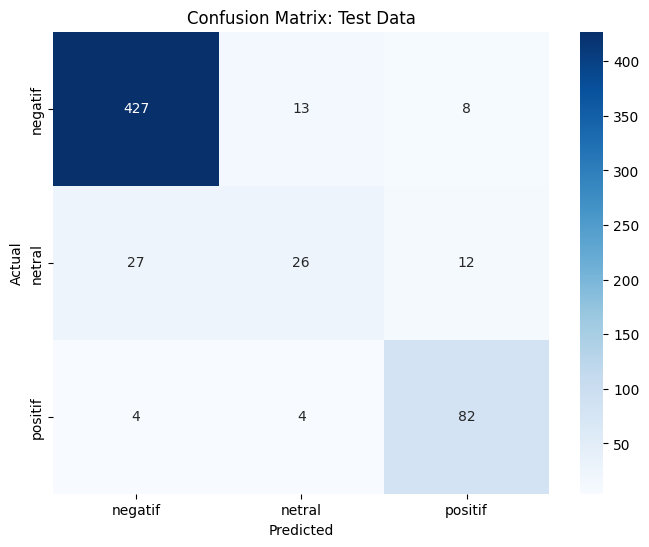

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def professional_eval(trainer, dataset, split_name="Test"):
    """Consolidated professional evaluation function."""
    results = trainer.predict(dataset)
    y_pred = np.argmax(results.predictions, axis=-1)
    y_true = results.label_ids

    print(f"\n--- FINAL {split_name.upper()} REPORT ---")
    # Use 'test_roc_auc' as the key since trainer.predict on test set prefixes metrics with 'test_'
    roc_auc_key = f"{split_name.lower().replace(' ', '_')}_roc_auc" if f"{split_name.lower().replace(' ', '_')}_roc_auc" in results.metrics else 'test_roc_auc'

    if roc_auc_key in results.metrics:
        print(f"ROC AUC (Weighted): {results.metrics[roc_auc_key]:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=list(label2id.keys())))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label2id.keys(), yticklabels=label2id.keys())
    plt.title(f'Confusion Matrix: {split_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run final evaluation on Test Set
professional_eval(weighted_trainer, dataset_dict['test'], split_name='Test Data')

### **1. Check Training Progress**
We analyze the log history to ensure the model is learning and not overfitting.

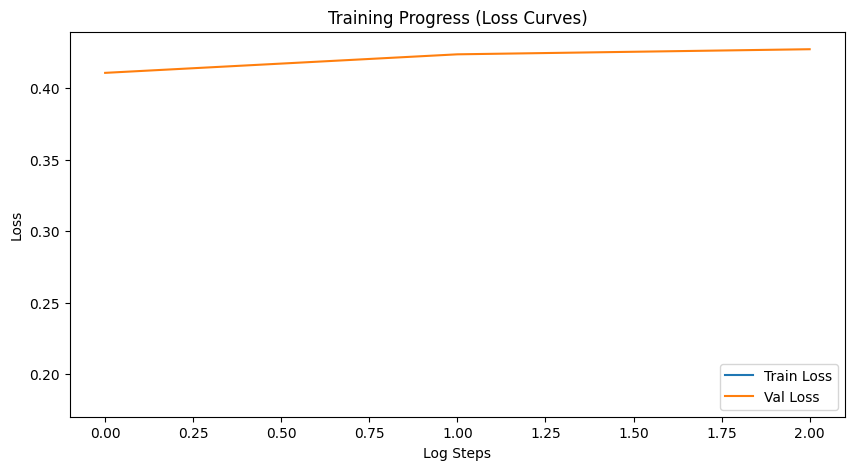

In [18]:
import matplotlib.pyplot as plt

# Visualize training history to check for convergence
history = weighted_trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Val Loss')
plt.title('Training Progress (Loss Curves)')
plt.xlabel('Log Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

### **2. Fine-tune (Optional Adjustment)**
If the results above show underfitting or overfitting, you can adjust the learning rate or epochs here and re-train.

In [19]:
# Example: Fine-tuning with a lower learning rate
# fine_tune_args = TrainingArguments(
#     output_dir="results_finetuned",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=1e-5, # Lower LR for fine-tuning
#     per_device_train_batch_size=16,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     load_best_model_at_end=True,
#     metric_for_best_model="roc_auc",
#     report_to="none"
# )

# Update trainer and run again if needed
# weighted_trainer.args = fine_tune_args
# weighted_trainer.train()

# **Test Model**

In [20]:
# Final step: Export results to CSV for thesis reporting
# Re-initializing the trainer briefly to fix the AcceleratorState error
weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    compute_metrics=compute_metrics,
    class_weights_tensor=initial_class_weights,
)

results = weighted_trainer.predict(dataset_dict['test'])
y_pred = np.argmax(results.predictions, axis=-1)

test_results_df = pd.DataFrame({
    'text': X_test.tolist(),
    'true_label': [id2label[i] for i in y_test],
    'predicted_label': [id2label[i] for i in y_pred]
})

output_path = '/content/drive/MyDrive/Thesis/results/final_indobert_test_results.csv'
test_results_df.to_csv(output_path, index=False)
print(f"Professional report exported to: {output_path}")

Professional report exported to: /content/drive/MyDrive/Thesis/results/final_indobert_test_results.csv


### **Class Distribution Analysis**

/tmp/ipykernel_617/1796809358.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=label_counts.values, palette='viridis')


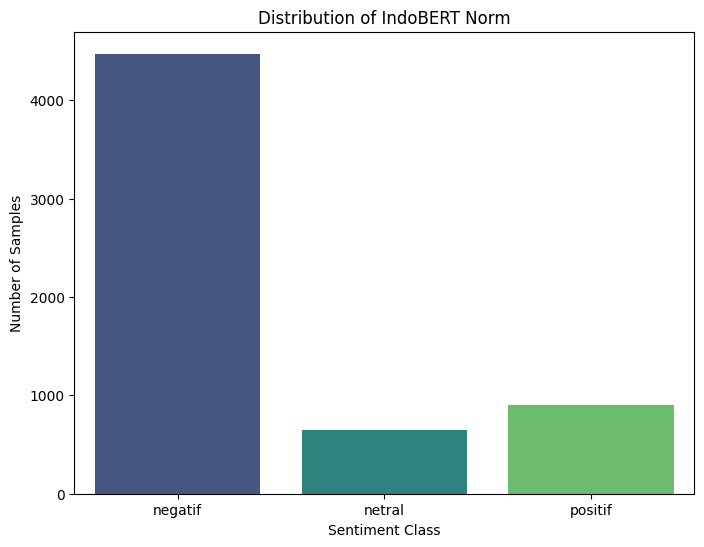

Label Distribution:
sentiment
negatif    4472
netral      650
positif     906
Name: count, dtype: int64


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the sentiment column
label_counts = df['sentiment'].value_counts().sort_index()

# Map numerical labels back to descriptive names for plotting
labels = [id2label[i] for i in label_counts.index]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=label_counts.values, palette='viridis')
plt.title('Distribution of IndoBERT Norm')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.show()

print("Label Distribution:")
print(label_counts.rename(index=id2label))

In [22]:
# import numpy as np
# from sklearn.preprocessing import label_binarize
# from sklearn.metrics import roc_curve, auc, roc_auc_score
# import torch
# import os
# from sklearn.utils.class_weight import compute_class_weight
# import torch.nn as nn
# from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, BertForSequenceClassification, BertTokenizer, AutoConfig
# import evaluate
# import matplotlib.pyplot as plt

# # --- Configuration for saving ROC data ---
# ROC_MODEL_NAME = "IndoBERT-Lexnorm"
# ROC_SAVE_DIR = "/content/drive/MyDrive/Thesis/results/roc_data" # Updated path
# NUM_CLASSES = 3

# # Re-define essential variables to ensure they are available
# MODEL_NAME = "indobenchmark/indobert-base-p1"
# id2label = {0: "negatif", 1: "netral", 2: "positif"}
# label2id = {"negatif": 0, "netral": 1, "positif": 2}

# # Re-initialize model to ensure it's defined and configure num_labels explicitly
# config = AutoConfig.from_pretrained(MODEL_NAME)
# config.num_labels = NUM_CLASSES
# config.id2label = id2label
# config.label2id = label2id

# model = BertForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     config=config,
# )

# # Recalculate weights if initial_class_weights is not available globally
# if 'initial_class_weights' not in globals() and 'y_train' in globals():
#     weights = compute_class_weight(
#         class_weight='balanced',
#         classes=np.unique(y_train),
#         y=y_train
#     )
#     initial_class_weights = torch.tensor(weights, dtype=torch.float)
#     print(f"Calculated Initial Class Weights (on CPU): {initial_class_weights}")
# elif 'initial_class_weights' not in globals():
#     print("Warning: 'initial_class_weights' and 'y_train' not found. Trainer might use default loss. Assuming balanced weights for 3 classes.")
#     initial_class_weights = torch.tensor([1.0, 1.0, 1.0], dtype=torch.float)

# # Check and define training_args if not already defined
# if 'training_args' not in globals():
#     print("Warning: 'training_args' not found. Defining a default for ROC plotting.")
#     training_args = TrainingArguments(
#         output_dir = "results",
#         eval_strategy = "epoch",
#         save_strategy = "epoch",
#         learning_rate = 2e-5,
#         per_device_train_batch_size = 16,
#         per_device_eval_batch_size = 16,
#         num_train_epochs = 1,
#         weight_decay = 0.01,
#         load_best_model_at_end = True,
#         metric_for_best_model = "roc_auc",
#         logging_steps = 5,
#         report_to = "none",
#     )

# # Check and define compute_metrics if not already defined
# if 'compute_metrics' not in globals():
#     print("Warning: 'compute_metrics' not found. Defining for ROC plotting.")
#     load_accuracy = evaluate.load("accuracy")
#     load_f1 = evaluate.load("f1")
#     def compute_metrics(eval_pred):
#         logits, labels = eval_pred
#         predictions = np.argmax(logits, axis=-1)
#         accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
#         f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]

#         if len(np.unique(labels)) > 2:
#             labels_one_hot = np.eye(len(label2id))[labels]
#             predictions_scores = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
#             roc_auc = roc_auc_score(labels_one_hot, predictions_scores, average="weighted", multi_class='ovr')
#         else:
#             roc_auc = roc_auc_score(labels, predictions_scores[:, 1])

#         return {"accuracy": accuracy, "f1": f1, "roc_auc": roc_auc}

# # Define WeightedTrainer if not already defined
# if 'WeightedTrainer' not in globals():
#     class WeightedTrainer(Trainer):
#         def __init__(self, *args, class_weights_tensor=None, **kwargs):
#             super().__init__(*args, **kwargs)
#             self.class_weights_tensor = class_weights_tensor

#         def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
#             labels = inputs.get("labels")
#             outputs = model(**inputs)
#             logits = outputs.get("logits")

#             if self.class_weights_tensor is not None:
#                 if self.class_weights_tensor.device != model.device:
#                     self.class_weights_tensor = self.class_weights_tensor.to(model.device)

#             loss_fct = nn.CrossEntropyLoss(weight=self.class_weights_tensor)
#             loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
#             return (loss, outputs) if return_outputs else loss

# # Check and ensure dataset_dict is available
# if 'dataset_dict' not in globals() or 'test' not in dataset_dict:
#     raise RuntimeError("Error: 'dataset_dict' or its 'test' split is not found. Please run the data preparation cells first (e.g., 'fcuMEhivJ10P') to load and tokenize the dataset.")

# # Initialize the trainer
# weighted_trainer = WeightedTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=dataset_dict["train"],
#     eval_dataset=dataset_dict["validation"],
#     compute_metrics=compute_metrics,
#     class_weights_tensor=initial_class_weights,
# )

# def save_macro_roc_data(y_true, y_score, model_name, num_classes, save_dir="roc_data"):
#     """
#     y_true     : array-like, shape (n_samples,)      - true integer class labels
#     y_score    : array-like, shape (n_samples, n_classes) - predicted probabilities
#     model_name : str, e.g. "IndoBERT-Lexnorm" (used as filename, keep it filesystem-safe)
#     num_classes: int, number of classes (3 for negatif/netral/positif)
#     save_dir   : folder to save the .npz files into (create it once, reuse for all models)
#     """
#     os.makedirs(save_dir, exist_ok=True)

#     y_true = np.asarray(y_true)
#     y_score = np.asarray(y_score)

#     # Binarize true labels for one-vs-rest
#     y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
#     if num_classes == 2:
#         # label_binarize collapses to 1 column for 2 classes; expand back to 2
#         y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

#     # Compute ROC curve + AUC for each class
#     fpr_dict, tpr_dict = {}, {}
#     for i in range(num_classes):
#         fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])

#     # --- Macro-average: interpolate each class curve onto a common FPR grid, then average TPR ---
#     all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(num_classes)]))
#     mean_tpr = np.zeros_like(all_fpr)
#     for i in range(num_classes):
#         mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
#     mean_tpr /= num_classes

#     macro_auc = auc(all_fpr, mean_tpr)

#     out_path = os.path.join(save_dir, f"IndoBERT_Norm.npz")
#     np.savez(out_path, fpr=all_fpr, tpr=mean_tpr, auc=macro_auc)
#     print(f"Saved {model_name}: macro-average AUC = {macro_auc:.4f} to {out_path}")

#     return all_fpr, mean_tpr, macro_auc

# # --- For IndoBERT (transformer, using your existing code) ---
# # Get predictions and true labels from the trainer
# results = weighted_trainer.predict(dataset_dict['test'])
# y_true = results.label_ids
# logits = results.predictions

# # Apply softmax to get probabilities for each class
# y_score = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# save_macro_roc_data(y_true, y_score, model_name=ROC_MODEL_NAME, num_classes=NUM_CLASSES, save_dir=ROC_SAVE_DIR)


Saved PR Data for IndoBERT-Lexnorm: macro-average PR-AUC = 0.7970 to /content/drive/MyDrive/Thesis/results/pr_data/IndoBERT_Reg_PR.npz


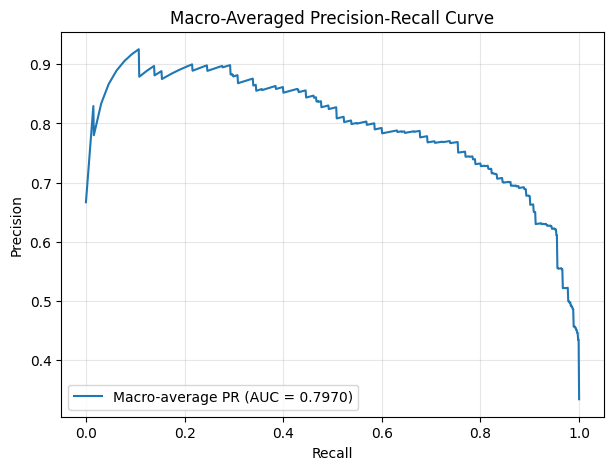

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score, auc
import torch

def save_macro_pr_data(y_true, y_score, model_name, num_classes, save_dir="/content/drive/MyDrive/Thesis/results/pr_data"):
    """
    Calculates macro-averaged Precision-Recall data and saves to .npz.
    """
    os.makedirs(save_dir, exist_ok=True)

    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    if num_classes == 2:
        y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

    # Precision and recall for each class
    precision_dict = {}
    recall_dict = {}

    # Use a common grid for interpolation (Recall from 0 to 1)
    mean_recall = np.linspace(0, 1, 1000)
    mean_precision = np.zeros_like(mean_recall)

    for i in range(num_classes):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        # Interpolate precision to the common recall grid
        # We flip them because precision_recall_curve returns recall in descending order
        mean_precision += np.interp(mean_recall, recall_dict[i][::-1], precision_dict[i][::-1])

    mean_precision /= num_classes
    macro_pr_auc = auc(mean_recall, mean_precision)

    out_path = os.path.join(save_dir, f"IndoBERT_Reg_PR.npz")
    np.savez(out_path, recall=mean_recall, precision=mean_precision, auc=macro_pr_auc)

    print(f"Saved PR Data for {model_name}: macro-average PR-AUC = {macro_pr_auc:.4f} to {out_path}")

    return mean_recall, mean_precision, macro_pr_auc

# --- Define required variables ---
# Assuming these are defined in a previous cell or need re-definition for standalone execution
ROC_MODEL_NAME = "IndoBERT-Reg" # Example name, adjust if needed
NUM_CLASSES = 3 # Based on previous cell context

# --- Get predictions and true labels from the trainer ---
# The 'weighted_trainer' and 'dataset_dict' are assumed to be defined in preceding cells
# If not, ensure those cells are run first or relevant objects are re-initialized.
results = weighted_trainer.predict(dataset_dict['test'])
y_true = results.label_ids
logits = results.predictions

# Apply softmax to get probabilities for each class
y_score = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# --- Calculate and Save PR Data ---
recall_grid, precision_grid, pr_auc = save_macro_pr_data(
    y_true=y_true,
    y_score=y_score,
    model_name=ROC_MODEL_NAME,
    num_classes=NUM_CLASSES,
    save_dir="/content/drive/MyDrive/Thesis/results/pr_data"
)

# Quick Plot visualization
plt.figure(figsize=(7, 5))
plt.plot(recall_grid, precision_grid, label=f'Macro-average PR (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()